# Scikit-learn: Data Preprocessing and Model Performance Evaluation
Objective: Build and compare Scikit-learn preprocessing pipelines and evaluate two classification models.

# Part A - Data Loading and Preprocessing with Scikit-learn


## Task 1 - Load and Understand the Dataset

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import KNNImputer, SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, MinMaxScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay

df = pd.read_csv("hotel_bookings.csv")

In [6]:
print("First 5 rows:")
display(df.head())

print("Shape:", df.shape)

print("\nDataset information:")
df.info()

print("\nDescriptive statistics:")
display(df.describe())

print("\nData types:")
display(df.dtypes)

print("\nClass distribution of is_canceled:")
display(df['is_canceled'].value_counts())

print("\nClass distribution (%):")
display(df['is_canceled'].value_counts(normalize=True) * 100)

y = df['is_canceled']
X = df.drop(columns='is_canceled')

numerical_cols = X.select_dtypes(include=np.number).columns.tolist()
categorical_cols = X.select_dtypes(exclude=np.number).columns.tolist()

print("\nNumerical columns:")
print(numerical_cols)

print("\nCategorical columns:")
print(categorical_cols)

First 5 rows:


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


Shape: (119390, 32)

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  object 
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  object 
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          1193

,is_canceled,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,booking_changes,agent,company,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests
count,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119386.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,103050.000000,6797.000000,119390.000000,119390.000000,119390.000000,119390.000000
mean,0.370416,104.011416,2016.156554,27.165173,15.798241,0.927599,2.500302,1.856403,0.103890,0.007949,0.031912,0.087118,0.137097,0.221124,86.693382,189.266735,2.321149,101.831122,0.062518,0.571363
std,0.482918,106.863097,0.707476,13.605138,8.780829,0.998613,1.908286,0.579261,0.398561,0.097436,0.175767,0.844336,1.497437,0.652306,110.774548,131.655015,17.594721,50.535790,0.245291,0.792798
min,0.000000,0.000000,2015.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,6.000000,0.000000,-6.380000,0.000000,0.000000
25%,0.000000,18.000000,2016.000000,16.000000,8.000000,0.000000,1.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,9.000000,62.000000,0.000000,69.290000,0.000000,0.000000
50%,0.000000,69.000000,2016.000000,28.000000,16.000000,1.000000,2.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,14.000000,179.000000,0.000000,94.575000,0.000000,0.000000
75%,1.000000,160.000000,2017.000000,38.000000,23.000000,2.000000,3.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,229.000000,270.000000,0.000000,126.000000,0.000000,1.000000
max,1.000000,737.000000,2017.000000,53.000000,31.000000,19.000000,50.000000,55.000000,10.000000,10.000000,1.000000,26.000000,72.000000,21.000000,535.000000,543.000000,391.000000,5400.000000,8.000000,5.000000



Data types:


...


Class distribution of is_canceled:


is_canceled
0    75166
1    44224
Name: count, dtype: int64


Class distribution (%):


is_canceled
0    62.958372
1    37.041628
Name: proportion, dtype: float64


Numerical columns:
['lead_time', 'arrival_date_year', 'arrival_date_week_number', 'arrival_date_day_of_month', 'stays_in_weekend_nights', 'stays_in_week_nights', 'adults', 'children', 'babies', 'is_repeated_guest', 'previous_cancellations', 'previous_bookings_not_canceled', 'booking_changes', 'agent', 'company', 'days_in_waiting_list', 'adr', 'required_car_parking_spaces', 'total_of_special_requests']

Categorical columns:
['hotel', 'arrival_date_month', 'meal', 'country', 'market_segment', 'distribution_channel', 'reserved_room_type', 'assigned_room_type', 'deposit_type', 'customer_type', 'reservation_status', 'reservation_status_date']


## Task 2 - Missing Values, Leakage, and Outliers

,Missing Count,Missing Percentage
company,112593,94.306893
agent,16340,13.686238
country,488,0.408744
children,4,0.003350
arrival_date_month,0,0.000000
arrival_date_week_number,0,0.000000
hotel,0,0.000000
is_canceled,0,0.000000
stays_in_weekend_nights,0,0.000000
arrival_date_day_of_month,0,0.000000


Columns with very high missingness:


,Missing Count,Missing Percentage
company,112593,94.306893


Columns removed due to data leakage:
['reservation_status', 'reservation_status_date']


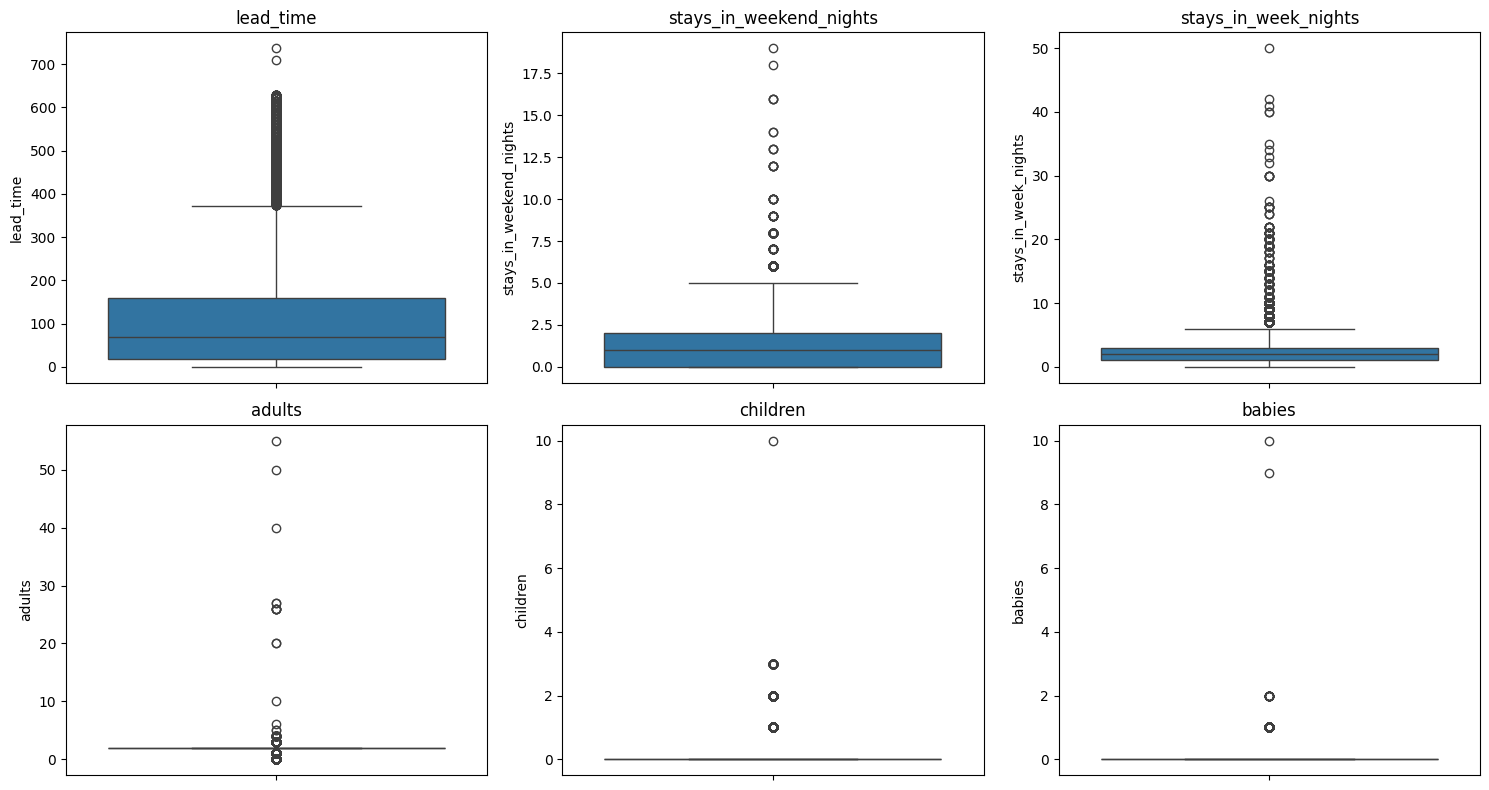

lead_time                   3005
stays_in_weekend_nights      265
stays_in_week_nights        3354
adults                     29710
children                    8590
babies                       917
Name: Outlier Count, dtype: int64

Rows removed as clear/extreme outliers: 14
Shape after removing clear/extreme outliers: (119376, 32)


In [7]:
# Missing values: count and percentage
missing_count = df.isnull().sum()
missing_percentage = (missing_count / len(df)) * 100

missing_summary = pd.DataFrame({
    'Missing Count': missing_count,
    'Missing Percentage': missing_percentage
}).sort_values('Missing Percentage', ascending=False)

display(missing_summary)

# Identify columns with very high missingness
print("Columns with very high missingness:")
display(missing_summary[missing_summary['Missing Percentage'] > 50])

# Remove columns that directly reveal the final booking outcome
X = X.drop(columns=['reservation_status', 'reservation_status_date'])

print("Columns removed due to data leakage:")
print(['reservation_status', 'reservation_status_date'])

# Check selected numerical features for outliers using IQR
outlier_cols = ['lead_time', 'stays_in_weekend_nights', 'stays_in_week_nights', 'adults', 'children', 'babies']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))

for ax, col in zip(axes.ravel(), outlier_cols):
    sns.boxplot(y=df[col], ax=ax)
    ax.set_title(col)

plt.tight_layout()
plt.show()

# IQR-based outlier counts
outlier_summary = {}

for col in outlier_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outlier_summary[col] = ((df[col] < lower_bound) | (df[col] > upper_bound)).sum()

display(pd.Series(outlier_summary, name='Outlier Count'))

# Remove only clear/extreme outliers
outlier_mask = (
    (df['adults'] > 10) |
    (df['children'] > 10) |
    (df['babies'] > 5) |
    (df['stays_in_weekend_nights'] > 20) |
    (df['stays_in_week_nights'] > 50)
)

print("Rows removed as clear/extreme outliers:", outlier_mask.sum())

df = df.loc[~outlier_mask].copy()
y = df['is_canceled']
X = df.drop(columns=['is_canceled', 'reservation_status', 'reservation_status_date'])

print("Shape after removing clear/extreme outliers:", df.shape)

In [8]:
X = X.drop(columns='company')

print("Final X shape:", X.shape)
print("Company column removed due to 94.31% missing values.")

Final X shape: (119376, 28)
Company column removed due to 94.31% missing values.


## Task 3 - Create Two Preprocessing Pipelines

In [9]:
# Update feature column lists after Task 2 cleaning
numerical_cols = X.select_dtypes(include=np.number).columns.tolist()
categorical_cols = X.select_dtypes(exclude=np.number).columns.tolist()

# Split the data using the same split for all experiments
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

# Numerical preprocessing for Pipeline A
numerical_pipeline_A = Pipeline([
    ('imputer', KNNImputer(n_neighbors=5)),
    ('scaler', StandardScaler())
])

# Numerical preprocessing for Pipeline B
numerical_pipeline_B = Pipeline([
    ('imputer', KNNImputer(n_neighbors=5)),
    ('scaler', MinMaxScaler())
])

# Categorical preprocessing
categorical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

# ColumnTransformer for Pipeline A
preprocessor_A = ColumnTransformer([
    ('num', numerical_pipeline_A, numerical_cols),
    ('cat', categorical_pipeline, categorical_cols)
])

# ColumnTransformer for Pipeline B
preprocessor_B = ColumnTransformer([
    ('num', numerical_pipeline_B, numerical_cols),
    ('cat', categorical_pipeline, categorical_cols)
])

print("Training set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)
print("Numerical features:", len(numerical_cols))
print("Categorical features:", len(categorical_cols))

Training set shape: (95500, 28)
Testing set shape: (23876, 28)
Numerical features: 18
Categorical features: 10


# Part B - Model Training and Performance Evaluation

## Task 4 - Train Two Classification Models

In [ ]:
# Logistic Regression with Pipeline A (StandardScaler)
logistic_A = Pipeline([
    ('preprocessor', preprocessor_A),
    ('model', LogisticRegression(max_iter=1000))
])

# Logistic Regression with Pipeline B (MinMaxScaler)
logistic_B = Pipeline([
    ('preprocessor', preprocessor_B),
    ('model', LogisticRegression(max_iter=1000))
])

# Decision Tree with Pipeline A (StandardScaler)
tree_A = Pipeline([
    ('preprocessor', preprocessor_A),
    ('model', DecisionTreeClassifier(random_state=42))
])

# Decision Tree with Pipeline B (MinMaxScaler)
tree_B = Pipeline([
    ('preprocessor', preprocessor_B),
    ('model', DecisionTreeClassifier(random_state=42))
])

# Train all four model-pipeline combinations
logistic_A.fit(X_train, y_train)
logistic_B.fit(X_train, y_train)
tree_A.fit(X_train, y_train)
tree_B.fit(X_train, y_train)

print("All four model-pipeline combinations trained successfully.")

## Task 5 - Evaluate and Compare the Four Results

In [12]:
# Logistic Regression with Pipeline A (StandardScaler)
logistic_A = Pipeline([
    ('preprocessor', preprocessor_A),
    ('model', LogisticRegression(max_iter=1000))
])

# Logistic Regression with Pipeline B (MinMaxScaler)
logistic_B = Pipeline([
    ('preprocessor', preprocessor_B),
    ('model', LogisticRegression(max_iter=1000))
])

# Decision Tree with Pipeline A (StandardScaler)
tree_A = Pipeline([
    ('preprocessor', preprocessor_A),
    ('model', DecisionTreeClassifier(random_state=42))
])

# Decision Tree with Pipeline B (MinMaxScaler)
tree_B = Pipeline([
    ('preprocessor', preprocessor_B),
    ('model', DecisionTreeClassifier(random_state=42))
])

logistic_A.fit(X_train, y_train)
logistic_B.fit(X_train, y_train)
tree_A.fit(X_train, y_train)
tree_B.fit(X_train, y_train)

print("All four model-pipeline combinations trained successfully.")

All four model-pipeline combinations trained successfully.


## Task 5 - Evaluate and Compare the Four Results

,Model-Pipeline,Training Accuracy,Testing Accuracy,Precision,Recall,F1-Score,Train-Test Gap
0,Logistic Regression + StandardScaler,0.8192,0.8161,0.8057,0.6636,0.7278,0.0031
1,Logistic Regression + MinMaxScaler,0.8154,0.8116,0.8004,0.6544,0.7201,0.0038
2,Decision Tree + StandardScaler,0.9960,0.8599,0.8076,0.8160,0.8118,0.1362
3,Decision Tree + MinMaxScaler,0.9960,0.8594,0.8067,0.8159,0.8113,0.1366


Best Logistic Regression: Logistic Regression + StandardScaler
Best Decision Tree: Decision Tree + StandardScaler


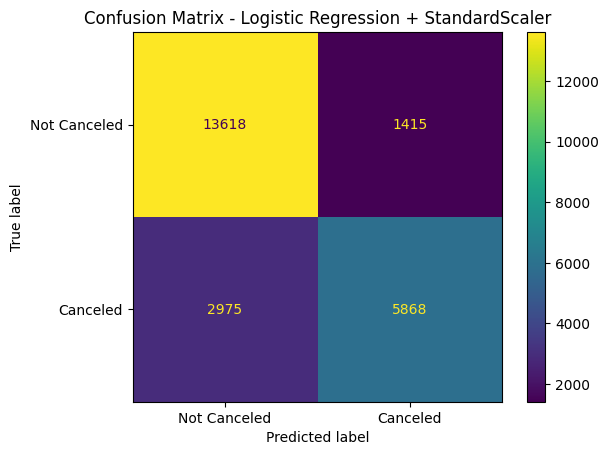

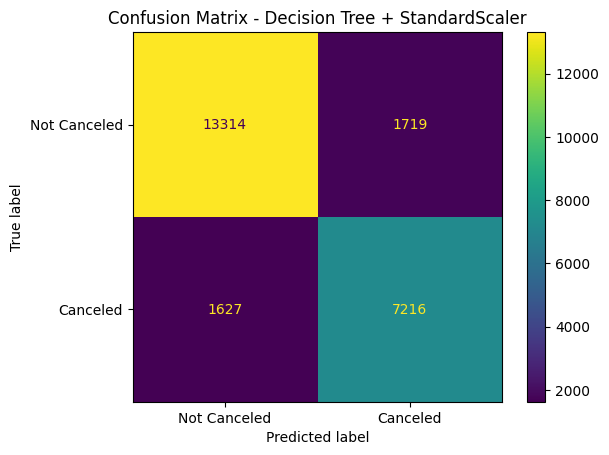

Train-Test Performance Difference:


,Model-Pipeline,Train-Test Gap
3,Decision Tree + MinMaxScaler,0.1366
2,Decision Tree + StandardScaler,0.1362
1,Logistic Regression + MinMaxScaler,0.0038
0,Logistic Regression + StandardScaler,0.0031


In [14]:
# Task 5: Evaluate and Compare the Four Results

models = {
    'Logistic Regression + StandardScaler': logistic_A,
    'Logistic Regression + MinMaxScaler': logistic_B,
    'Decision Tree + StandardScaler': tree_A,
    'Decision Tree + MinMaxScaler': tree_B
}

results = []

for name, model in models.items():
    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)

    train_accuracy = accuracy_score(y_train, train_pred)
    test_accuracy = accuracy_score(y_test, test_pred)
    precision = precision_score(y_test, test_pred)
    recall = recall_score(y_test, test_pred)
    f1 = f1_score(y_test, test_pred)

    results.append([
        name,
        train_accuracy,
        test_accuracy,
        precision,
        recall,
        f1,
        train_accuracy - test_accuracy
    ])

results_df = pd.DataFrame(
    results,
    columns=[
        'Model-Pipeline',
        'Training Accuracy',
        'Testing Accuracy',
        'Precision',
        'Recall',
        'F1-Score',
        'Train-Test Gap'
    ]
)

display(results_df.round(4))

# Best Logistic Regression based on testing F1-score
logistic_results = results_df[
    results_df['Model-Pipeline'].str.startswith('Logistic Regression')
]

best_logistic_name = logistic_results.loc[
    logistic_results['F1-Score'].idxmax(), 'Model-Pipeline'
]

# Best Decision Tree based on testing F1-score
tree_results = results_df[
    results_df['Model-Pipeline'].str.startswith('Decision Tree')
]

best_tree_name = tree_results.loc[
    tree_results['F1-Score'].idxmax(), 'Model-Pipeline'
]

print("Best Logistic Regression:", best_logistic_name)
print("Best Decision Tree:", best_tree_name)

# Confusion matrix for best Logistic Regression
best_logistic_model = models[best_logistic_name]
ConfusionMatrixDisplay.from_predictions(
    y_test,
    best_logistic_model.predict(X_test),
    display_labels=['Not Canceled', 'Canceled']
)
plt.title(f'Confusion Matrix - {best_logistic_name}')
plt.show()

# Confusion matrix for best Decision Tree
best_tree_model = models[best_tree_name]
ConfusionMatrixDisplay.from_predictions(
    y_test,
    best_tree_model.predict(X_test),
    display_labels=['Not Canceled', 'Canceled']
)
plt.title(f'Confusion Matrix - {best_tree_name}')
plt.show()

# Overfitting check
print("Train-Test Performance Difference:")
display(
    results_df[['Model-Pipeline', 'Train-Test Gap']]
    .sort_values('Train-Test Gap', ascending=False)
    .round(4)
)

### Final Observations

1. **Decision Tree + StandardScaler gives the best overall result**, with the highest testing accuracy (85.99%) and F1-score (81.18%). It also achieves the highest recall (81.60%), correctly identifying more canceled bookings than the other models.

2. **StandardScaler affects Logistic Regression more than MinMaxScaler.** Logistic Regression with StandardScaler achieves a testing accuracy of 81.61% and F1-score of 72.78%, compared with 81.16% and 72.01% using MinMaxScaler. Therefore, StandardScaler performs slightly better for Logistic Regression.

3. **Scaling makes very little difference to the Decision Tree.** The testing accuracy changes only from 85.99% with StandardScaler to 85.94% with MinMaxScaler, while the F1-score changes from 81.18% to 81.13%. This shows that the choice of scaling method has almost no practical effect on the Decision Tree.

4. **The Decision Tree shows signs of substantial overfitting.** Its training accuracy is 99.60%, while its testing accuracy is only about 85.99%, giving a train-test gap of 13.62 percentage points. In contrast, Logistic Regression has much smaller gaps of 0.31–0.38 percentage points, indicating more consistent generalization.

5. **The confusion matrices show that the Decision Tree is better at detecting canceled bookings.** The best Decision Tree correctly identifies 7,216 canceled bookings, compared with 5,868 for the best Logistic Regression. However, the Decision Tree also produces 1,719 false positives, compared with 1,415 for Logistic Regression. Overall, the Decision Tree provides better predictive performance despite its greater tendency to overfit.